In [1]:
%load_ext autoreload
%matplotlib widget

from helper_funcs import *
from collections import defaultdict
import numpy as np
import pandas as pd


dirs = get_dirs(root=r"c:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")
dpi = 500

In [2]:
# Get data
def get_data(T_xi_types):
    data = defaultdict(lambda: defaultdict(dict))

    for T_xi_type in T_xi_types:
        # Read df
        df = pd.read_excel(os.path.join(
            dirs["results"], rf"soae_T_xi [{T_xi_type}].xlsx"
        ))

        dfs = {}
        dfs["P"] = df[df["mode"]=="P"]
        dfs["phi"] = df[df["mode"]=="phi"]
        has_P = not (len(dfs["P"]) == 0)

        # Gather everything into lists
        if "cgram" in T_xi_type:
            prop_list = ["T_xi", "species", "wf_idx", "f0"]
            N_xi_multiplier = "f0"
        else:
            prop_list = ["T_xi", "species", "wf_idx", "f0_max", "f0_fit"]
            N_xi_multiplier = "f0_max"

        for mode in ["phi", "P"]:
            if not has_P and mode == "P":
                continue
            for prop in prop_list:
                data[T_xi_type][mode][prop] = np.array(dfs[mode][prop])
  
            # Calculate derived data
            data[T_xi_type][mode]["N_xi"] = data[T_xi_type][mode]["T_xi"] * data[T_xi_type][mode][N_xi_multiplier]
            data[T_xi_type][mode]["inv_T_xi"] = 1/(data[T_xi_type][mode]["T_xi"])
        if has_P:
            data[T_xi_type]["T_xi_diffs"] = data[T_xi_type]["P"]["T_xi"] - data[T_xi_type]["phi"]["T_xi"]
            data[T_xi_type]["N_xi_diffs"] = data[T_xi_type]["P"]["N_xi"] - data[T_xi_type]["phi"]["N_xi"]

    return data
peakc_filt_id = f"bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None"

dict_keys(['int 25ms, bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None', 'int 500ms, bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None'])


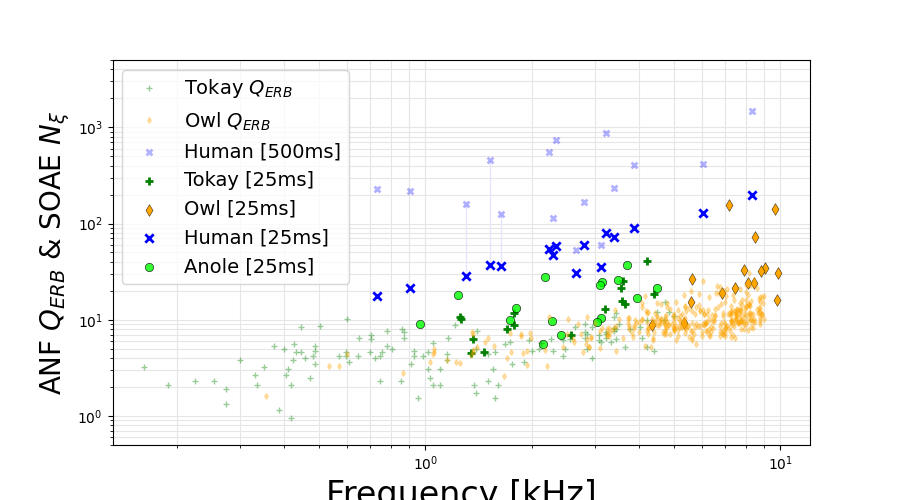

In [ ]:
"Qerb and N_xi vs Freq"
meth_id_peak_centric = f"int 25ms, {peakc_filt_id}"
meth_id_peak_centric_long = f"int 500ms, {peakc_filt_id}"

data = get_data((meth_id_peak_centric, meth_id_peak_centric_long))
fig_fp_id = f"int {meth_id_peak_centric[4:8]} ({meth_id_peak_centric_long[4:8]} Human)"

print(data.keys())

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["N_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{fig_fp_id}].jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
    
    # Plot Q_ERB
    plt.plot(
        freqANFtokay,
        QerbANFtokay,
        "+",
        color="green",
        alpha=0.4,
        ms=4,
        lw=1,
        markerfacecolor="green",
        label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    plt.plot(
        freqANFowl,
        QerbANFowl,
        "d",
        color="orange",
        alpha=0.3,
        ms=3,
        lw=1,
        markerfacecolor="orange",
        label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    # Plot Human
    human_mask = [sp == "Human" for sp in data[meth_id_peak_centric_long]["phi"]["species"]]
    plt.scatter(
            (data[meth_id_peak_centric_long]["phi"]["f0_max"] / 1000)[human_mask],
            data[meth_id_peak_centric_long]["phi"][tc][human_mask],
            marker=markers["Human"],
            color=colors["Human"],
            lw=mews["Human"],
            alpha=alpha_human_long,
            s=s_human_long,
            facecolors=mfcs["Human"],
            label=f"Human [{meth_id_peak_centric_long[4:9]}]",
        )
    
    # Plot deltas
    mask_deltas = [sp == "Human" and freq > delta_mask_fmin and freq < delta_mask_fmax for sp, freq in zip(data[meth_id_peak_centric]["phi"]["species"], data[meth_id_peak_centric]["phi"]["f0_max"])]
    plt.vlines(
        data[meth_id_peak_centric]["phi"]["f0_max"][mask_deltas] / 1000,
        ymin=np.minimum(data[meth_id_peak_centric]["phi"]["N_xi"][mask_deltas], data[meth_id_peak_centric_long]["phi"]["N_xi"][mask_deltas]),
        ymax=np.maximum(data[meth_id_peak_centric]["phi"]["N_xi"][mask_deltas], data[meth_id_peak_centric_long]["phi"]["N_xi"][mask_deltas]),
        lw=1,
        color="blue",
        zorder=0,
        alpha=alpha_human_line
    )


    # Plot X_xis
    for s in set(data[meth_id_peak_centric]["phi"]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric]["phi"]["species"]]

        plt.scatter(
            (data[meth_id_peak_centric]["phi"]["f0_max"] / 1000)[mask_species],
            data[meth_id_peak_centric]["phi"][tc][mask_species],
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            label=f"{s} [{meth_id_peak_centric[4:8]}]",
        )
    




    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(0.5, 5e3)
    elif tc=="T_xi":
        plt.ylim(1e-3, 1e2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"ANF $Q_{{ERB}}$ & SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

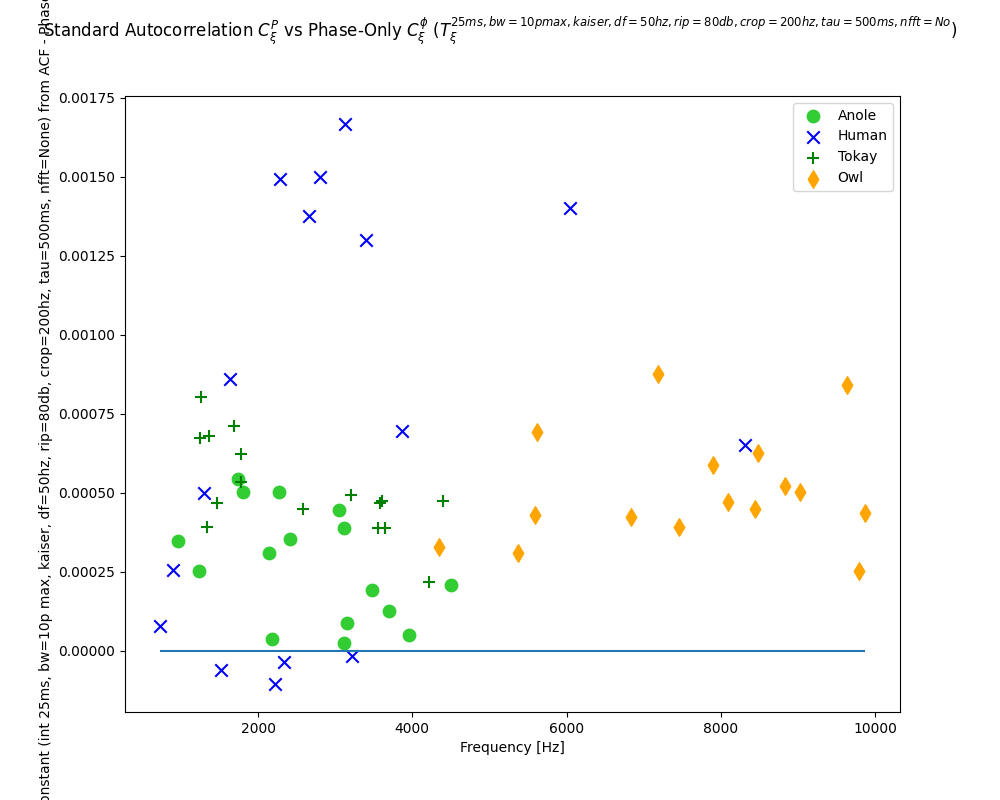

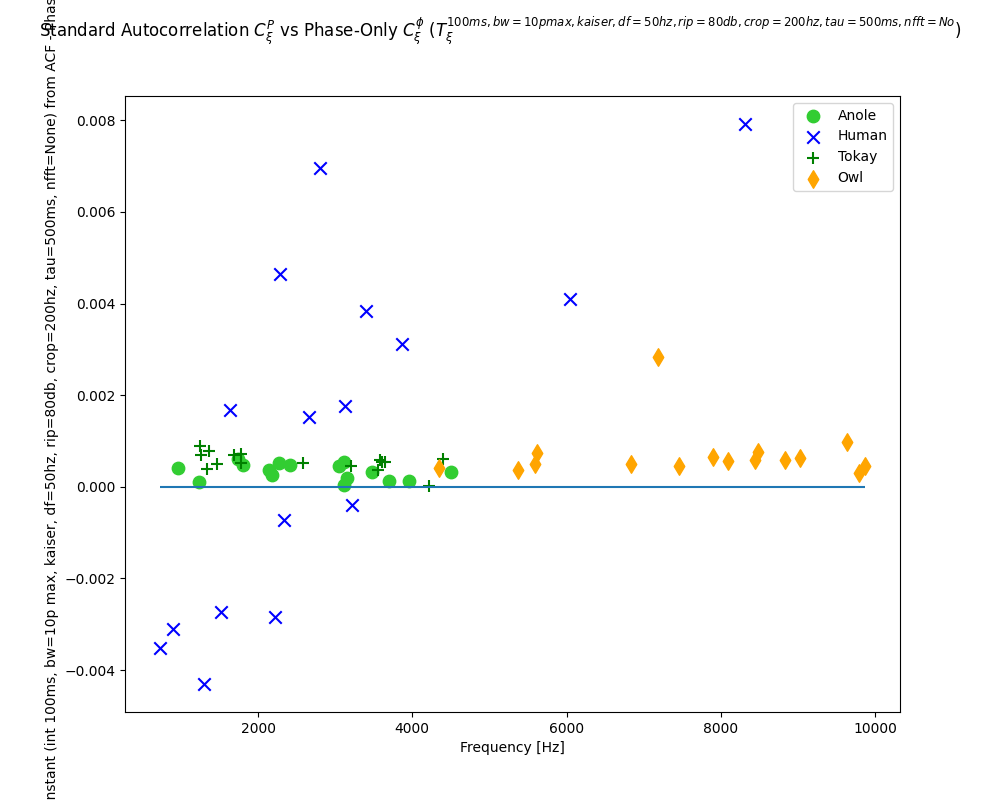

In [4]:
"Standard Autocorrelation vs Phase-Only"
T_xi_types = ["int 25ms, bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None", "int 100ms, bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None"]
data = get_data(T_xi_types)

for T_xi_type in T_xi_types:
    for tc in ["T_xi"]:
        # Initialize plot
        plt.figure(figsize=(10, 8))
        plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ (${tc[0]}_\xi^{{{T_xi_type[4:-2]}}}$)")
        fn_plot = f'Phase only vs ACF ({tc[0]}_xi_{T_xi_type}).jpg'

        f0_maxs = data[T_xi_type]["P"]["f0_max"]
        speciess = data[T_xi_type]["P"]["species"]

        if np.max(np.abs(f0_maxs-data[T_xi_type]["phi"]["f0_max"])) > 0 or np.any(speciess != data[T_xi_type]["phi"]["species"]):
            raise ValueError("Frequencies and species should agree between modes!")


        markers = {
            "Anole": ("limegreen", "o"),
            "Owl": ("orange", "d"),
            "Human": ("blue", "x"),
            "Tokay": ("green", "+"),
        }

        unique_species = ["Anole", "Human", "Tokay", "Owl"]

        for species in unique_species:
            f0_maxs_plot = [this_f0_max for this_f0_max, this_species in zip(f0_maxs, speciess) if this_species == species]
            if tc == "N_xi":
                N_xi_diff_plot = [this_N_xi_diff for this_N_xi_diff, this_species in zip(data[T_xi_type]["N_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, N_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
            elif tc == "T_xi":
                T_xi_diff_plot = [this_T_xi_diff for this_T_xi_diff, this_species in zip(data[T_xi_type]["T_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, T_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
        plt.hlines(0, np.min(f0_maxs), np.max(f0_maxs))
        plt.xlabel("Frequency [Hz]")
        plt.ylabel(f"Time Constant ({T_xi_type}) from ACF - Phase Only")
        plt.legend()
        plt.savefig(os.path.join(dirs["figs"], fn_plot), dpi=dpi)

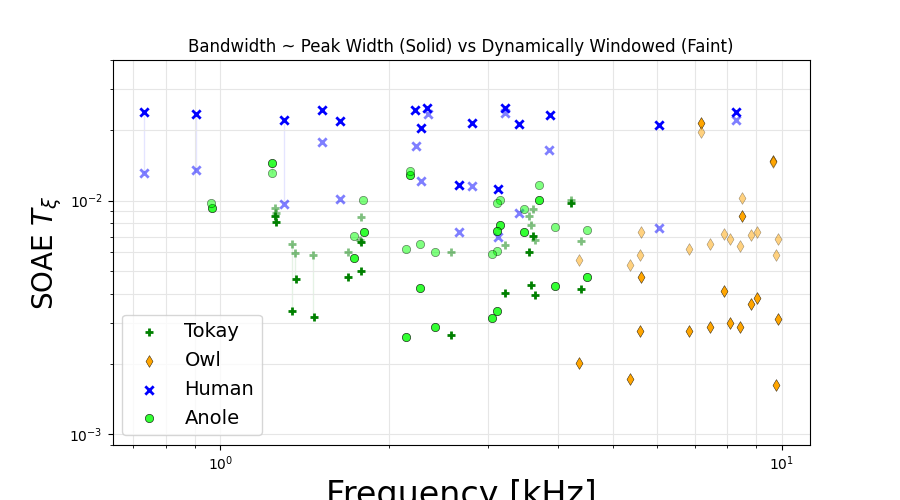

In [30]:
"N_xi from Cgram vs from peak-centric"
meth_id_peak_centric = "int 25ms, bw=10p max, kaiser, df=50hz, rip=80db, crop=200hz, tau=500ms, nfft=None"
meth_id_cgram = "cgram int 25ms, delta_xi=1ms, rho=1.0, Hann, HPF=(300Hz cf, 50Hz df, 100dB rip), tau=150ms, hop=10ms, nfft=8192"


data = get_data((meth_id_peak_centric, meth_id_cgram))

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["T_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Cgram vs Peak-centric {tc} [{meth_id_cgram} vs {meth_id_peak_centric}].jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    alphas_cgram = {"Anole": 0.5, "Owl": 0.5, "Human": 0.5, "Tokay": 0.5}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
    
    # Plot Q_ERB
    # plt.plot(
    #     freqANFtokay,
    #     QerbANFtokay,
    #     "+",
    #     color="green",
    #     alpha=0.4,
    #     ms=4,
    #     lw=1,
    #     markerfacecolor="green",
    #     label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    # )

    # plt.plot(
    #     freqANFowl,
    #     QerbANFowl,
    #     "d",
    #     color="orange",
    #     alpha=0.3,
    #     ms=3,
    #     lw=1,
    #     markerfacecolor="orange",
    #     label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    # )
    



    # Plot X_xis
    for s in set(data[meth_id_peak_centric]["phi"]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric]["phi"]["species"]]
        mask_species_cgram = [sp == s for sp in data[meth_id_cgram]["phi"]["species"]]
        # Plot peak_centric ones for this species (easy part)
        f0_species_peak_centric = data[meth_id_peak_centric]["phi"]["f0_max"][mask_species]
        tc_species_peak_centric = data[meth_id_peak_centric]["phi"][tc][mask_species]

        plt.scatter(
            f0_species_peak_centric/1000,
            tc_species_peak_centric,
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            label=f"{s}"
        )
        for wf_idx in range(4):
            # Make wf_idx mask
            mask_idx = [idx == wf_idx for idx in data[meth_id_peak_centric]["phi"]["wf_idx"][mask_species]]
            mask_idx_cgram = [idx == wf_idx for idx in data[meth_id_cgram]["phi"]["wf_idx"][mask_species_cgram]]

            # Get the f0s from both methods so we can compare them
            peak_centric_f0s = data[meth_id_peak_centric]["phi"]["f0_max"][mask_species][mask_idx]
            cgram_f0s = data[meth_id_cgram]["phi"]["f0"][mask_species_cgram][mask_idx_cgram]

            # Make the cgram mask matching cgram values to the peak-centric values
            nearest_cgram_f0_idxs = np.argmin(np.abs(cgram_f0s[:, None] - peak_centric_f0s[None, :]), axis=0)
            mask_f0_cgram = np.zeros(len(cgram_f0s), dtype=bool) 
            mask_f0_cgram[nearest_cgram_f0_idxs] = True

            # Select cgram values using the mask
            f0s_species_idx_cgram = cgram_f0s[mask_f0_cgram]
            tc_species_idx_cgram = data[meth_id_cgram]["phi"][tc][mask_species_cgram][mask_idx_cgram][mask_f0_cgram]

            plt.scatter(
                (f0s_species_idx_cgram)/1000,
                tc_species_idx_cgram,
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas_cgram[s],
                s=36,
                facecolors=mfcs[s],
                # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            )

            # Plot deltas
            mask_deltas = [freq < 1500 for freq in f0s_species_idx_cgram]
            plt.vlines(
                f0s_species_idx_cgram[mask_deltas] / 1000,
                ymin=np.minimum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                ymax=np.maximum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                lw=1,
                color=colors[s],
                zorder=0,
                alpha=alpha_human_line
            )



    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(6, 300)
    elif tc=="T_xi":
        plt.ylim(9e-4, 4e-2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.title(f"Bandwidth ~ Peak Width (Solid) vs Dynamically Windowed (Faint)")
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()